# Systematic Model Evaluation

Evaluate all `augmented_{MODEL_NAME}_{NB_LAYERS}_layers.pth` checkpoints on the validation set, with and without TTA. Results are compiled into two JSON files.

In [1]:
import os
import json
import torch
import torchmetrics
import numpy as np
import h5py
import warnings
import torchvision.transforms.functional as F
from tqdm.notebook import tqdm

from dlmi.utils import set_seed, get_device
from dlmi.dataset import H5Dataset, get_dataloader
from dlmi.model import get_finetunable_dinov2
from dlmi.transforms import get_ood_transform
from dlmi.test import evaluate_no_tta, evaluate_with_tta

warnings.filterwarnings("ignore", category=UserWarning)

## Configuration

In [ ]:
VAL_PATH = "../data/val.h5"
MODELS_DIR = "../models"
RESULTS_DIR = "../results"
IMG_SIZE = 98
BATCH_SIZE = 16
SEED = 0

MODEL_NAMES = ["dinov2_vits14", "dinov2_vitb14", "dinov2_vitl14"]
NB_LAYERS_LIST = [2, 3, 5, 7, 10]

set_seed(SEED)
device = get_device()
print(f"Device: {device}")

Device: mps


## Prepare validation data

In [3]:
val_preprocessing = get_ood_transform(size=IMG_SIZE, train=False)
val_ds = H5Dataset(VAL_PATH, transform=val_preprocessing, mode="train")
val_loader = get_dataloader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
print(f"Val: {len(val_ds)} samples")

Val: 34904 samples


## Run evaluation over all model checkpoints

In [ ]:
results_no_tta = {}
results_tta = {}

for model_name in MODEL_NAMES:
    for nb_layers in NB_LAYERS_LIST:
        key = f"{model_name}_{nb_layers}_layers"
        model_path = os.path.join(MODELS_DIR, f"augmented_{key}.pth")

        if not os.path.exists(model_path):
            print(f"[SKIP] {model_path} not found")
            continue

        print(f"\n{'=' * 60}")
        print(f"Evaluating: {key}")
        print(f"{'=' * 60}")

        model = get_finetunable_dinov2(
            model_name, num_blocks_to_unfreeze=nb_layers, device=device
        )
        model.load_state_dict(torch.load(model_path, weights_only=True))
        model.eval()

        # Without TTA
        acc_no_tta = evaluate_no_tta(model, val_loader, device)
        results_no_tta[key] = acc_no_tta
        print(f"  No TTA accuracy: {acc_no_tta:.4f}")

        # With TTA
        acc_tta = evaluate_with_tta(model, VAL_PATH, val_preprocessing, device)
        results_tta[key] = acc_tta
        print(f"  TTA accuracy:    {acc_tta:.4f}")

print(f"\n\nEvaluated {len(results_no_tta)} models.")

## Save results to JSON

In [ ]:
os.makedirs(RESULTS_DIR, exist_ok=True)

no_tta_path = os.path.join(RESULTS_DIR, "val_results_no_tta.json")
tta_path = os.path.join(RESULTS_DIR, "val_results_tta.json")

with open(no_tta_path, "w") as f:
    json.dump(results_no_tta, f, indent=2)

with open(tta_path, "w") as f:
    json.dump(results_tta, f, indent=2)

print(f"Saved: {no_tta_path}")
print(f"Saved: {tta_path}")

## Summary table

In [ ]:
import pandas as pd

rows = []
for key in results_no_tta:
    rows.append(
        {
            "model": key,
            "accuracy_no_tta": results_no_tta[key],
            "accuracy_tta": results_tta[key],
        }
    )

df = pd.DataFrame(rows)
df.style.highlight_max(subset=["accuracy_no_tta", "accuracy_tta"], color="lightgreen")

## Heatmap — Without TTA

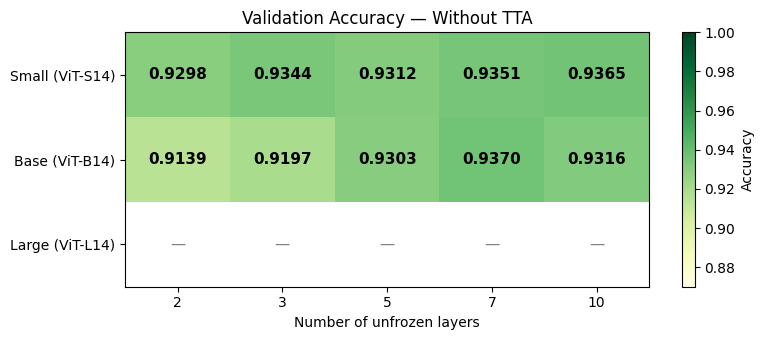

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

MODEL_NAMES = ["dinov2_vits14", "dinov2_vitb14", "dinov2_vitl14"]
ROW_LABELS = ["Small (ViT-S14)", "Base (ViT-B14)", "Large (ViT-L14)"]
NB_LAYERS_LIST = [2, 3, 5, 7, 10]

with open("../results/val_results_no_tta.json") as f:
    data = json.load(f)

grid = np.full((len(MODEL_NAMES), len(NB_LAYERS_LIST)), np.nan)
for i, model_name in enumerate(MODEL_NAMES):
    for j, nb in enumerate(NB_LAYERS_LIST):
        key = f"{model_name}_{nb}_layers"
        if key in data:
            grid[i, j] = data[key]

fig, ax = plt.subplots(figsize=(8, 3.5))
norm = mcolors.Normalize(vmin=0.87, vmax=1.0)
im = ax.imshow(grid, cmap="YlGn", norm=norm, aspect="auto")

for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        val = grid[i, j]
        if not np.isnan(val):
            ax.text(
                j,
                i,
                f"{val:.4f}",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
            )
        else:
            ax.text(j, i, "—", ha="center", va="center", fontsize=11, color="gray")

ax.set_xticks(range(len(NB_LAYERS_LIST)))
ax.set_xticklabels(NB_LAYERS_LIST)
ax.set_yticks(range(len(ROW_LABELS)))
ax.set_yticklabels(ROW_LABELS)
ax.set_xlabel("Number of unfrozen layers")
ax.set_title("Validation Accuracy — Without TTA")
fig.colorbar(im, ax=ax, label="Accuracy")
plt.tight_layout()
plt.show()

## Heatmap — With TTA

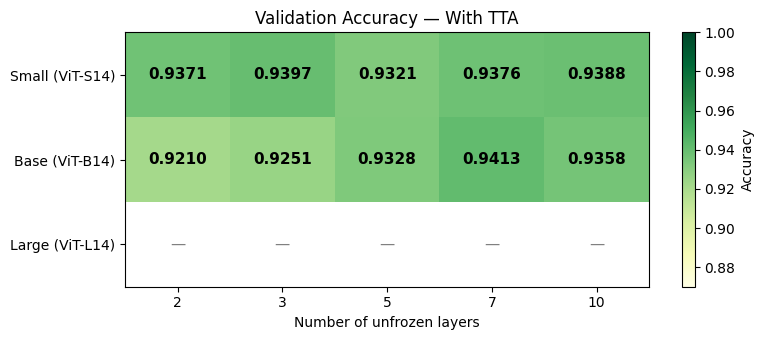

In [10]:
with open("../results/val_results_tta.json") as f:
    data_tta = json.load(f)

grid_tta = np.full((len(MODEL_NAMES), len(NB_LAYERS_LIST)), np.nan)
for i, model_name in enumerate(MODEL_NAMES):
    for j, nb in enumerate(NB_LAYERS_LIST):
        key = f"{model_name}_{nb}_layers"
        if key in data_tta:
            grid_tta[i, j] = data_tta[key]

fig, ax = plt.subplots(figsize=(8, 3.5))
norm = mcolors.Normalize(vmin=0.87, vmax=1.0)
im = ax.imshow(grid_tta, cmap="YlGn", norm=norm, aspect="auto")

for i in range(grid_tta.shape[0]):
    for j in range(grid_tta.shape[1]):
        val = grid_tta[i, j]
        if not np.isnan(val):
            ax.text(
                j,
                i,
                f"{val:.4f}",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
            )
        else:
            ax.text(j, i, "—", ha="center", va="center", fontsize=11, color="gray")

ax.set_xticks(range(len(NB_LAYERS_LIST)))
ax.set_xticklabels(NB_LAYERS_LIST)
ax.set_yticks(range(len(ROW_LABELS)))
ax.set_yticklabels(ROW_LABELS)
ax.set_xlabel("Number of unfrozen layers")
ax.set_title("Validation Accuracy — With TTA")
fig.colorbar(im, ax=ax, label="Accuracy")
plt.tight_layout()
plt.show()